# Sales Prediction Using Machine Learning

## Objective

The objective of this project is to predict product sales based on advertising expenditure on TV, Radio, and Newspaper using machine learning algorithms.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv('advertising.csv')
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## dataset preview 

- the dataset contains advertising expenditure on tv ,radio and newspaper

In [4]:
print("dataset shape:", df.shape)

dataset shape: (200, 5)


In [6]:
print(df.dtypes)

Unnamed: 0      int64
TV            float64
radio         float64
newspaper     float64
sales         float64
dtype: object


In [7]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64


In [8]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


# Exploratory Data Analysis (EDA)

EDA helps understand the structure of the dataset before training machine learning models.

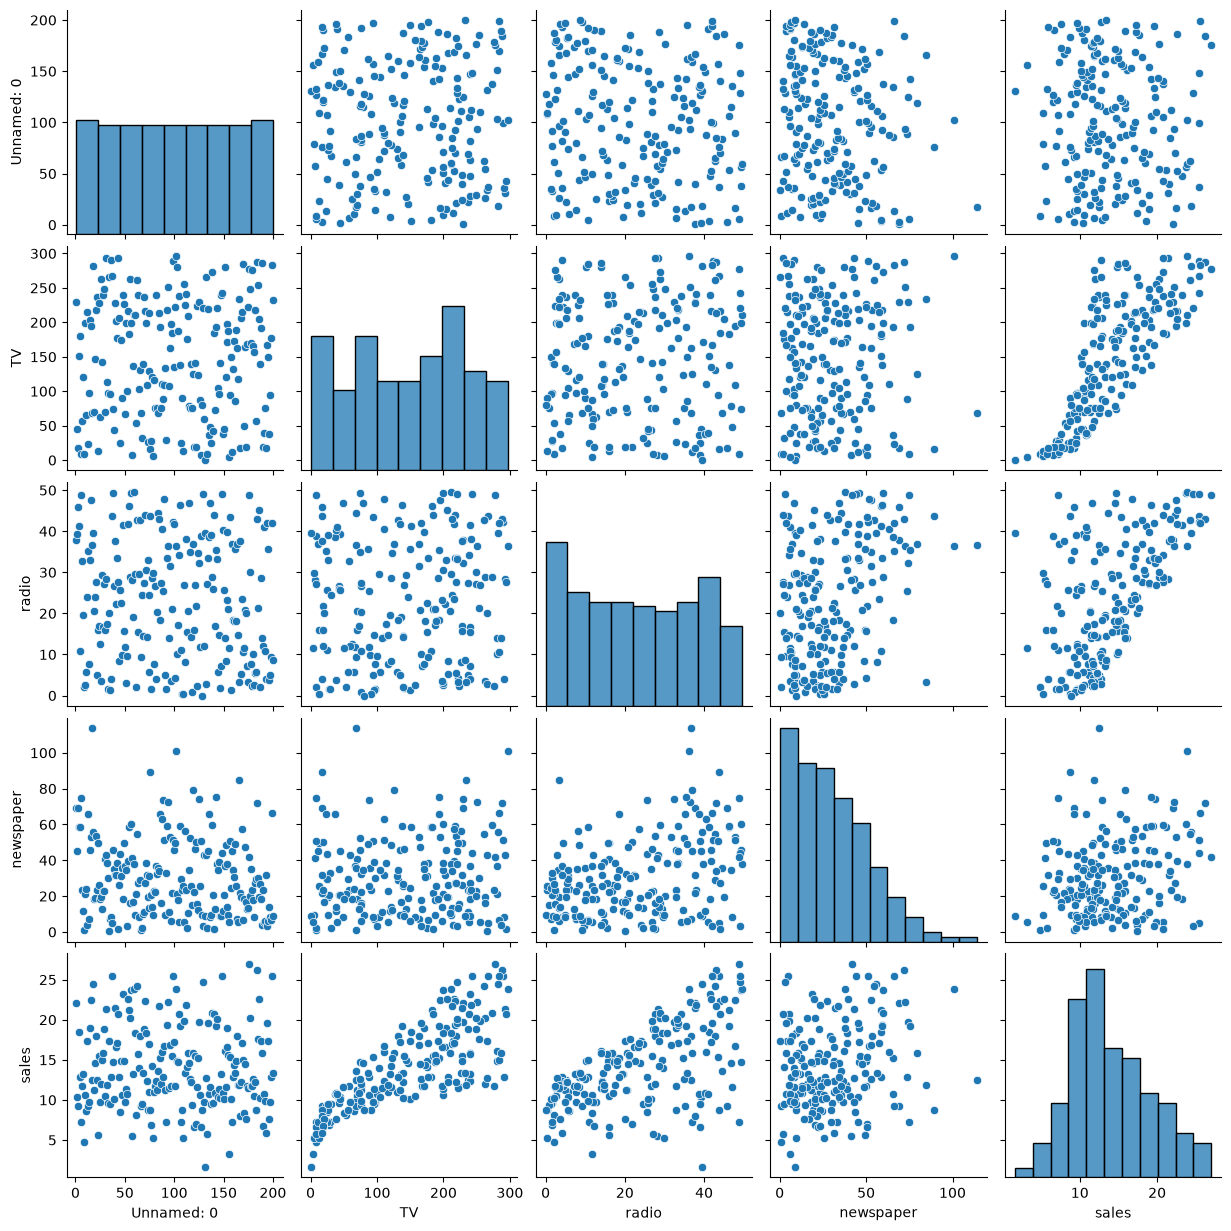

In [10]:
sns.pairplot(df)

plt.show()

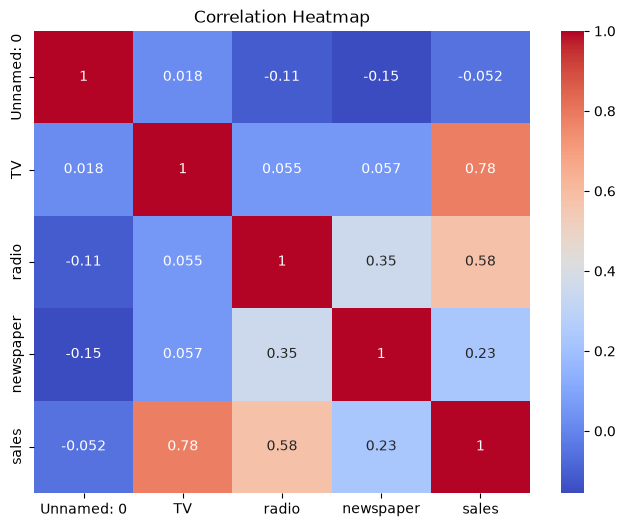

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [17]:
print(df.columns)

Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='str')


In [18]:
df.columns.tolist()

['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales']

In [19]:
df.rename(columns={
    "radio": "Radio",
    "newspaper": "Newspaper",
    "sales": "Sales"
}, inplace=True)

df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

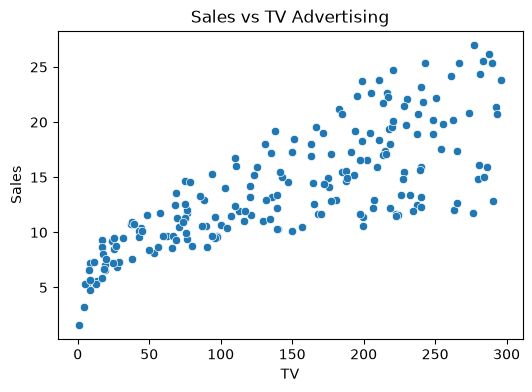

In [21]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="TV",
    y="Sales",
    data=df
)

plt.title("Sales vs TV Advertising")

plt.show()

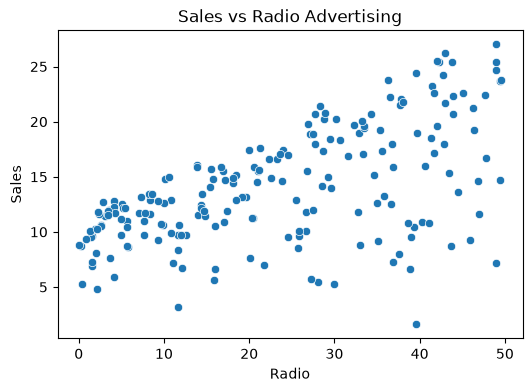

In [22]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Radio",
    y="Sales",
    data=df
)

plt.title("Sales vs Radio Advertising")

plt.show()

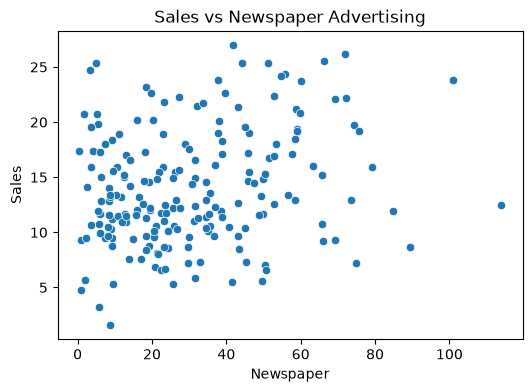

In [23]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Newspaper",
    y="Sales",
    data=df
)

plt.title("Sales vs Newspaper Advertising")

plt.show()

## Observations

- TV advertising shows a strong positive relationship with Sales.
- Radio advertising also has a positive relationship with Sales.
- Newspaper advertising appears to have a weaker relationship with Sales.

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (160, 4)
Testing Data Shape: (40, 4)


In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Linear Regression Evaluation")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression Evaluation
MAE : 1.4650601050102936
RMSE : 1.7885761008659677
R2 Score : 0.8986489151417079


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [28]:
print("Random Forest Evaluation")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Evaluation
MAE : 0.6703249999999988
RMSE : 0.8239788377136873
R2 Score : 0.978489739464474


In [29]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.465060,1.788576,0.898649
1,Random Forest,0.670325,0.823979,0.978490


# Best Model

The Random Forest Regressor achieved better prediction performance than Linear Regression based on the evaluation metrics.

Therefore, Random Forest is selected as the best-performing model for this project.





# Conclusion

In this project, machine learning regression models were developed to predict product sales based on advertising expenditure.

Exploratory Data Analysis showed that TV advertising has the strongest positive relationship with sales, followed by Radio advertising, while Newspaper advertising has a comparatively weaker impact.

Both Linear Regression and Random Forest Regressor were trained and evaluated using MAE, RMSE, and R² Score.

Based on the evaluation metrics, the Random Forest Regressor demonstrated better prediction performance and was selected as the final model.

This project demonstrates how machine learning can help businesses estimate future sales and optimize advertising budgets.